In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

In [18]:
class Adaline:
    def __init__(self, learning_rate=0.01, num_epochs=100):
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1] + 1)  # Khởi tạo trọng số và ngưỡng
        self.costs = []

        for _ in range(self.num_epochs):
            output = self.predict(X)
            errors = y - output
            self.weights[1:] += self.learning_rate * X.T.dot(errors)  # Cập nhật trọng số
            self.weights[0] += self.learning_rate * errors.sum()  # Cập nhật ngưỡng
            cost = (errors ** 2).sum() / 2.0  # Hàm mất mát (mean squared error)
            self.costs.append(cost)

    def predict(self, X):
        activation = np.dot(X, self.weights[1:]) + self.weights[0]
        return np.where(activation >= 0.0, 1, -1)

In [19]:
iris = load_iris()
X = iris.data[:, :2]  # Consider only the first two features for simplicity
y = np.where(iris.target == 0, -1, 1)  # Convert labels to -1 and 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
adaline = Adaline(learning_rate=0.01, num_epochs=100)
adaline.fit(X_train, y_train)

# Dữ liệu dự đoán
y_pred = adaline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 1.0


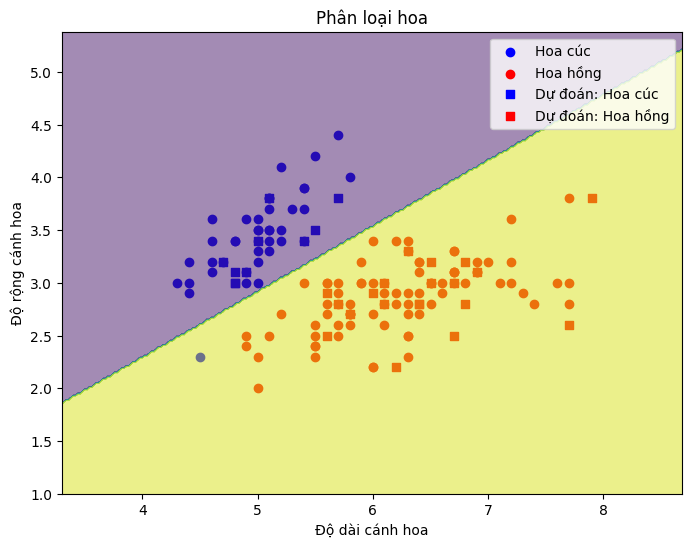

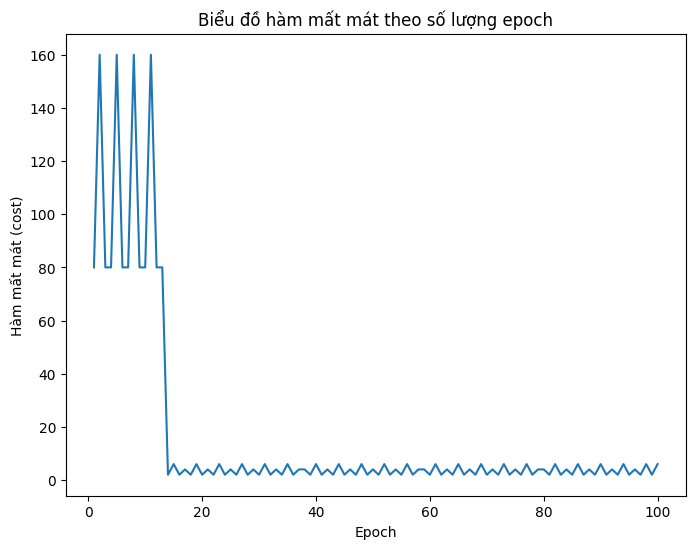

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], color='blue', label='Hoa cúc')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='red', label='Hoa hồng')
plt.scatter(X_test[y_pred == -1, 0], X_test[y_pred == -1, 1], color='blue', marker='s', label='Dự đoán: Hoa cúc')
plt.scatter(X_test[y_pred == 1, 0], X_test[y_pred == 1, 1], color='red', marker='s', label='Dự đoán: Hoa hồng')
plt.xlabel('Độ dài cánh hoa')
plt.ylabel('Độ rộng cánh hoa')
plt.legend()
plt.title('Phân loại hoa')

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = adaline.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.5)
plt.show()

# Trực quan hóa biểu đồ hàm mất mát
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(adaline.costs) + 1), adaline.costs)
plt.xlabel('Epoch')
plt.ylabel('Hàm mất mát (cost)')
plt.title('Biểu đồ hàm mất mát theo số lượng epoch')
plt.show()